# Credit Underwriting Analysis — Nu Mexico
### Exploratory data analysis of the acquisition funnel, risk performance, and underwriting operations

**Dataset.** 520,000 credit applications (Jul 2025 – Jun 2026), their decisions, the underwriting
operational trace, 12 months of account performance (2.69M account-months), and pre-application
in-app behavioural features.

**What this notebook establishes, in order:**

1. Data inventory and integrity of the five tables and their join keys.
2. The acquisition funnel: where the 520k applications end up.
3. **The single largest structural finding** — the composition of declines.
4. **Validity gates** — the checks that decide which inferences this data can support (run *before* any risk inference).
5. A natural experiment hidden in the data (`pilot_holdout`) that provides the counterfactual for declined applicants.
6. Whether behavioural data carries risk signal where the bureau is silent.
7. A cross-validated scorecard that sizes the opportunity, with confidence intervals.
8. Underwriting operations: where analyst capacity is spent and what latency costs.
9. Economics, under explicit and sensitivity-tested assumptions.

> **Headline.** 157k applications/year — 30% of all volume — are declined for *having no credit
> bureau history*, not for bad credit. A randomised holdout shows this population is not
> uniformly risky: behavioural data ranks it well enough that its safest ~30% defaults at
> **2.39%**, statistically indistinguishable from the **2.42%** of the book currently being
> approved. Separately, these same auto-declined applications consume **53% of all analyst
> review hours**.

## 0 · Setup

In [2]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import PercentFormatter, FuncFormatter

DATA = Path("../data")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# ---- Visual system -------------------------------------------------------------------
# Validated categorical palette (slots 1-3 clear all-pairs CVD + normal-vision gates).
# Every chart is direct-labelled, which satisfies the relief rule for low-contrast hues.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GOOD, CRITICAL, WARNING = "#0ca30c", "#d03b3b", "#fab219"
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8880", "#e6e5e1"
# Ordinal blue ramp — light end no lighter than step 250 so it stays >= 2:1 on the surface.
BLUES = ["#86b6ef", "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 120, "font.size": 10.5,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "legend.frameon": False, "xtick.bottom": False, "ytick.left": False,
    "lines.linewidth": 2, "lines.markersize": 6,
})

def style(ax, xgrid=False, ygrid=True):
    """Recessive grid on the measure axis only."""
    ax.xaxis.grid(xgrid); ax.yaxis.grid(ygrid)
    return ax

def label_bars(ax, bars, fmt="{:.2f}", pad=None, color=INK, orient="v"):
    """Direct labels — never a legend where a label will do."""
    halo = [pe.withStroke(linewidth=2.6, foreground=SURFACE)]   # keeps labels legible over ref lines
    if orient == "v":
        pad = pad if pad is not None else (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + pad, fmt.format(b.get_height()),
                    ha="center", va="bottom", fontsize=9.5, color=color, zorder=6,
                    path_effects=halo)
    else:
        pad = pad if pad is not None else (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.012
        for b in bars:
            ax.text(b.get_width() + pad, b.get_y() + b.get_height()/2, fmt.format(b.get_width()),
                    va="center", ha="left", fontsize=9.5, color=color, zorder=6,
                    path_effects=halo)

thousands = FuncFormatter(lambda v, _: f"{v/1000:,.0f}k" if v >= 1000 else f"{v:,.0f}")
print("Setup complete.")

Setup complete.


## 1 · Data inventory and integrity

Before any analysis, establish what each table is keyed on, whether the keys are unique, and
whether the joins are lossless. An unnoticed fan-out here would silently corrupt every rate
computed downstream.

In [3]:
apps  = pd.read_parquet(DATA / "credit_applications.parquet")
dec   = pd.read_parquet(DATA / "credit_decisions.parquet")
ops   = pd.read_parquet(DATA / "underwriting_ops.parquet")
perf  = pd.read_parquet(DATA / "credit_performance.parquet")
beh   = pd.read_parquet(DATA / "app_behavior_features.parquet")

tables = {"credit_applications": apps, "credit_decisions": dec, "underwriting_ops": ops,
          "credit_performance": perf, "app_behavior_features": beh}

inv = pd.DataFrame([{
    "table": n,
    "rows": f"{len(t):,}",
    "cols": t.shape[1],
    "customers": f"{t.customer_id.nunique():,}",
    "mem_MB": round(t.memory_usage(deep=True).sum() / 1e6, 1),
    "null_cols": ", ".join(t.columns[t.isna().any()]) or "—",
} for n, t in tables.items()])
inv

,table,rows,cols,customers,mem_MB,null_cols
0,credit_applications,"520,000",12,"520,000",59.400,bureau_score
1,credit_decisions,"520,000",6,"520,000",42.000,—
2,underwriting_ops,"520,000",9,"520,000",16.100,—
3,credit_performance,"2,693,334",8,"299,205",153.500,—
4,app_behavior_features,"520,000",11,"520,000",42.100,secured_card_utilization_pct


In [4]:
# ---- Key uniqueness and referential integrity ----------------------------------------
checks = []
def chk(name, passed, detail=""):
    checks.append({"check": name, "result": "PASS" if passed else "FAIL", "detail": detail})

chk("credit_applications.application_id unique", apps.application_id.is_unique, f"{apps.application_id.nunique():,} ids")
chk("one application per customer",              apps.customer_id.is_unique,    f"{apps.customer_id.nunique():,} customers")
chk("credit_decisions 1:1 with applications",
    dec.application_id.is_unique and set(dec.application_id) == set(apps.application_id))
chk("underwriting_ops 1:1 with applications",
    ops.application_id.is_unique and set(ops.application_id) == set(apps.application_id))
chk("behaviour features 1:1 with customers",
    beh.customer_id.is_unique and set(beh.customer_id) == set(apps.customer_id))

# performance is a panel: one row per account-month
chk("credit_performance keyed (account_id, observation_month)",
    not perf.duplicated(["account_id", "observation_month"]).any(),
    f"{perf.account_id.nunique():,} accounts x up to 12 months")
chk("account_id <-> customer_id is 1:1 in performance",
    perf.groupby("customer_id").account_id.nunique().eq(1).all())

approved_ids = set(dec.loc[dec.decision == "approved", "customer_id"])
perf_ids     = set(perf.customer_id)
chk("performance covers exactly the approved population",
    perf_ids == approved_ids,
    f"{len(perf_ids):,} in performance vs {len(approved_ids):,} approved; "
    f"declined customers present: {len(perf_ids - approved_ids):,}")

pd.DataFrame(checks)

,check,result,detail
0,credit_applications.application_id unique,PASS,"520,000 ids"
1,one application per customer,PASS,"520,000 customers"
2,credit_decisions 1:1 with applications,PASS,
3,underwriting_ops 1:1 with applications,PASS,
4,behaviour features 1:1 with customers,PASS,
5,"credit_performance keyed (account_id, observat...",PASS,"299,205 accounts x up to 12 months"
6,account_id <-> customer_id is 1:1 in performance,PASS,
7,performance covers exactly the approved popula...,PASS,"299,205 in performance vs 299,205 approved; de..."


**Integrity result.** A clean star schema: `credit_applications`, `credit_decisions`,
`underwriting_ops` and `app_behavior_features` are all strictly 1:1 on 520,000 rows, so they
can be joined without fan-out. `credit_performance` is a monthly panel over the **299,205
approved accounts only**.

That last point is the defining constraint of this dataset and shapes the entire analysis:

> **Performance data exists only for applicants who were approved.** There is no repayment
> outcome for the 220,795 declined applicants. This is textbook **reject inference** — the
> decision rule censors its own evaluation data, so a model trained on approved accounts cannot
> be validated on the population it would newly approve. §5 shows the one exception the data
> provides.

In [5]:
# ---- One application-level base table + the customer-level default label -------------
# default_flag_12m is verified constant within customer in §4, so max() is a safe collapse.
outcome = (perf.groupby("customer_id")
               .agg(default_12m=("default_flag_12m", "max"),
                    months_observed=("months_on_book", "max"),
                    max_dpd=("days_past_due", "max"),
                    avg_balance_mxn=("balance_mxn", "mean"),
                    credit_limit_mxn=("credit_limit_mxn", "mean"))
               .reset_index())

df = (apps.merge(dec,     on=["application_id", "customer_id"], how="inner", validate="1:1")
          .merge(ops,     on=["application_id", "customer_id"], how="inner", validate="1:1")
          .merge(beh,     on="customer_id",                     how="inner", validate="1:1")
          .merge(outcome, on="customer_id",                     how="left",  validate="1:1"))

df["thin_file"]    = ~df.bureau_hit                       # no bureau record = credit invisible
df["approved"]     = df.decision.eq("approved")
df["app_month"]    = df.application_ts.dt.to_period("M")

assert len(df) == len(apps), "join changed row count"
print(f"Base table: {len(df):,} applications x {df.shape[1]} columns")
print(f"Applications span {df.application_ts.min():%Y-%m-%d} to {df.application_ts.max():%Y-%m-%d}")
print(f"Default outcome available for {df.default_12m.notna().sum():,} "
      f"({df.default_12m.notna().mean():.1%}) — the approved population only")

Base table: 520,000 applications x 41 columns
Applications span 2025-07-01 to 2026-07-01
Default outcome available for 299,205 (57.5%) — the approved population only


### Monthly volume — is the process stable?

Worth settling early, because an unstable funnel would mean pooling twelve months of
applications together is invalid.

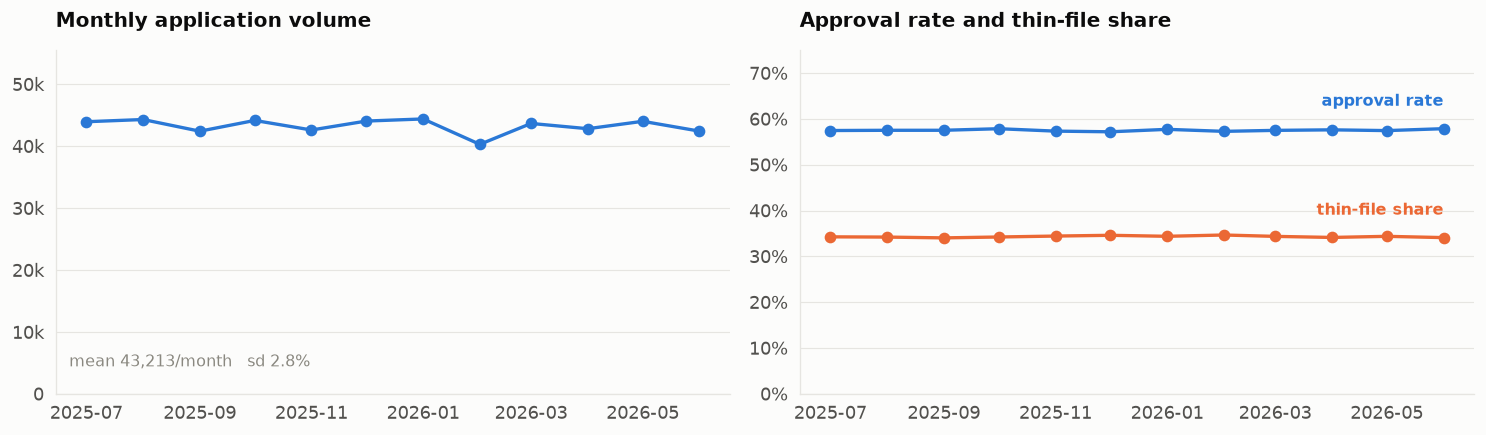

Excluded from trend: 1 partial month(s) — 1,447 applications on ['2026-07']
Volume    range: 40,251 – 44,348
Approval  range: 57.2% – 57.9%
Thin-file range: 34.0% – 34.7%


In [6]:
mth = (df.groupby("app_month")
         .agg(applications=("application_id", "size"),
              approval_rate=("approved", "mean"),
              thin_file_share=("thin_file", "mean"))
         .reset_index())
mth["app_month"] = mth.app_month.dt.to_timestamp()

# 2026-07 is a 1-day stub (the range ends 2026-07-01) — exclude from trend, never plot it as a month.
full = mth[mth.applications > 10_000].copy()
stub = mth[mth.applications <= 10_000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.9))

ax1.plot(full.app_month, full.applications, color=BLUE, marker="o")
ax1.set_ylim(0, full.applications.max() * 1.25)
ax1.yaxis.set_major_formatter(thousands)
ax1.set_title("Monthly application volume")
ax1.text(0.02, 0.08, f"mean {full.applications.mean():,.0f}/month   sd {full.applications.std()/full.applications.mean():.1%}",
         transform=ax1.transAxes, color=MUTED, fontsize=9.5)
style(ax1)

ax2.plot(full.app_month, full.approval_rate * 100, color=BLUE, marker="o")
ax2.plot(full.app_month, full.thin_file_share * 100, color=ORANGE, marker="o")
ax2.set_ylim(0, 75)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_title("Approval rate and thin-file share")
ax2.text(full.app_month.iloc[-1], full.approval_rate.iloc[-1] * 100 + 5, "approval rate",
         color=BLUE, ha="right", fontsize=9.5, fontweight="bold")
ax2.text(full.app_month.iloc[-1], full.thin_file_share.iloc[-1] * 100 + 5, "thin-file share",
         color=ORANGE, ha="right", fontsize=9.5, fontweight="bold")
style(ax2)

for ax in (ax1, ax2):
    for s in ax.get_xticklabels(): s.set_rotation(0)
fig.suptitle("")
plt.tight_layout(); plt.show()

print(f"Excluded from trend: {len(stub)} partial month(s) — {stub.applications.sum():,} applications "
      f"on {stub.app_month.dt.strftime('%Y-%m').tolist()}")
print(f"Volume    range: {full.applications.min():,} – {full.applications.max():,}")
print(f"Approval  range: {full.approval_rate.min():.1%} – {full.approval_rate.max():.1%}")
print(f"Thin-file range: {full.thin_file_share.min():.1%} – {full.thin_file_share.max():.1%}")

The funnel is **flat on all three measures** — volume within ±4% of ~43k/month, approval rate
pinned at 57.3–57.9%, thin-file share at 34.0–34.7%. There is no seasonality, no drift, and no
policy change inside the window.

Two consequences: pooling the twelve months is legitimate, and any finding below is a
*standing structural property* of the policy rather than a transient episode. It also means
nothing here can be diagnosed as "a recent regression" — the process has been in this state the
whole time.

## 2 · The acquisition funnel

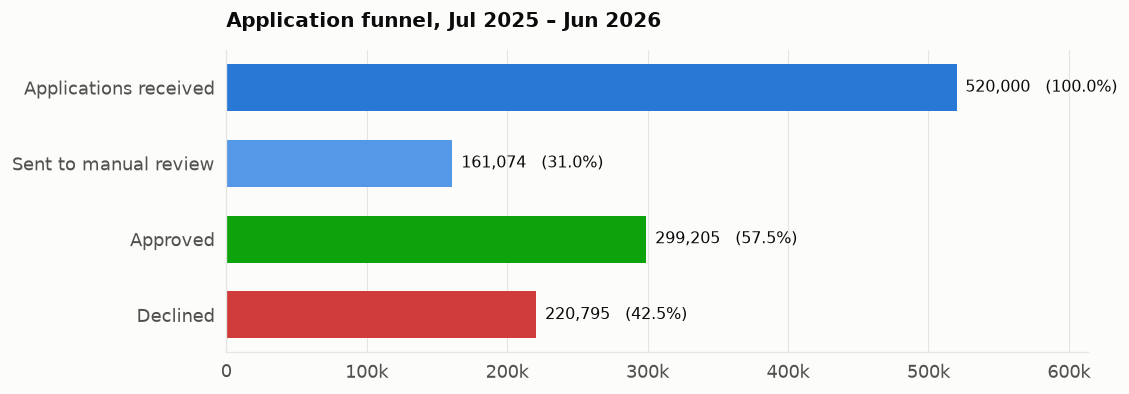

,stage,count,% of applications
0,Applications received,520000,100.000
1,Sent to manual review,161074,31.000
2,Abandoned before decision,27033,5.200
3,Approved,299205,57.500
4,Declined,220795,42.500


In [7]:
n_apps      = len(df)
n_abandoned = int(df.abandoned_before_decision.sum())
n_approved  = int(df.approved.sum())
n_declined  = n_apps - n_approved
n_manual    = int(df.manual_review_flag.sum())

funnel = pd.DataFrame({
    "stage": ["Applications received", "Sent to manual review", "Abandoned before decision",
              "Approved", "Declined"],
    "count": [n_apps, n_manual, n_abandoned, n_approved, n_declined],
})
funnel["% of applications"] = (funnel["count"] / n_apps * 100).round(1)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
seg = funnel.iloc[[0, 1, 3, 4]]
bars = ax.barh(seg.stage, seg["count"], color=[BLUES[3], BLUES[1], GOOD, CRITICAL], height=0.62)
ax.invert_yaxis(); ax.xaxis.set_major_formatter(thousands)
ax.set_xlim(0, n_apps * 1.18)
for b, (c, p) in zip(bars, zip(seg["count"], seg["% of applications"])):
    ax.text(c + n_apps * 0.012, b.get_y() + b.get_height()/2, f"{c:,}   ({p:.1f}%)",
            va="center", fontsize=9.5, color=INK)
ax.set_title("Application funnel, Jul 2025 – Jun 2026")
style(ax, xgrid=True, ygrid=False); plt.tight_layout(); plt.show()

funnel

57.5% approved, 42.5% declined. The interesting question is not the rate but its **composition** —
which is where the policy reveals itself.

## 3 · Why applications are declined

In [8]:
reason = (df.groupby("policy_reason")
            .agg(applications=("application_id", "size"),
                 bureau_hit_rate=("bureau_hit", "mean"),
                 mean_bureau_score=("bureau_score", "mean"),
                 mean_income_mxn=("declared_income_mxn", "mean"),
                 existing_nu_share=("existing_nu_customer", "mean"),
                 mean_limit_mxn=("approved_limit_mxn", "mean"))
            .sort_values("applications", ascending=False))
reason["% of all"] = (reason.applications / n_apps * 100).round(1)
reason

,applications,bureau_hit_rate,mean_bureau_score,mean_income_mxn,existing_nu_share,mean_limit_mxn,% of all
policy_reason,,,,,,,
approved_policy,282781,0.965,643.990,"10,697.040",0.670,"6,159.486",54.400
declined_no_bureau_history,156944,0.000,NaN,"10,211.615",0.591,0.000,30.200
declined_low_bureau_score,53248,1.000,500.336,"9,855.528",0.597,0.000,10.200
approved_pilot_holdout,16424,0.294,512.532,"9,983.045",0.589,"2,620.068",3.200
declined_insufficient_income,10603,1.000,579.417,"8,315.464",0.406,0.000,2.000


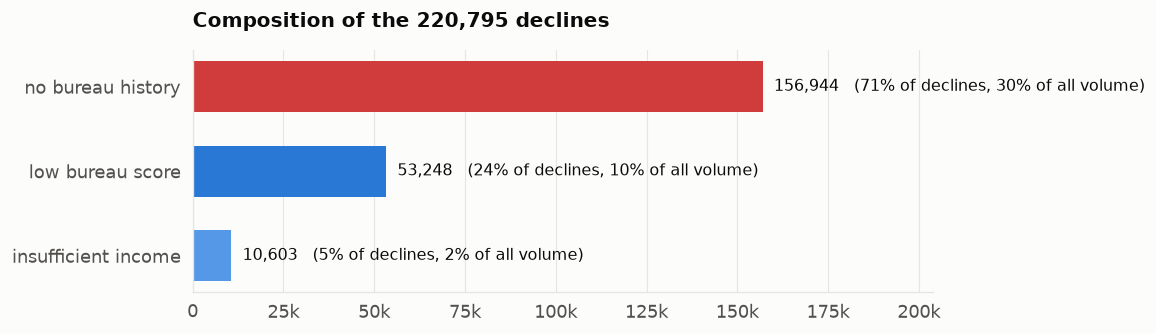

'no bureau history' is 71.1% of declines and 30.2% of total volume.
Thin-file applicants: 178,458 (34.3%) — of whom 87.9% are declined.


In [9]:
dcl = (df[~df.approved].policy_reason.value_counts()
         .rename(index=lambda s: s.replace("declined_", "").replace("_", " ")))

fig, ax = plt.subplots(figsize=(9.5, 2.9))
bars = ax.barh(dcl.index, dcl.values, color=[CRITICAL, BLUES[3], BLUES[1]], height=0.6)
ax.invert_yaxis(); ax.xaxis.set_major_formatter(thousands); ax.set_xlim(0, dcl.max() * 1.3)
for b, v in zip(bars, dcl.values):
    ax.text(v + dcl.max() * 0.02, b.get_y() + b.get_height()/2,
            f"{v:,}   ({v/n_declined:.0%} of declines, {v/n_apps:.0%} of all volume)",
            va="center", fontsize=9.5, color=INK)
ax.set_title("Composition of the 220,795 declines")
style(ax, xgrid=True, ygrid=False); plt.tight_layout(); plt.show()

print(f"'no bureau history' is {dcl.iloc[0]/n_declined:.1%} of declines and {dcl.iloc[0]/n_apps:.1%} of total volume.")
print(f"Thin-file applicants: {df.thin_file.sum():,} ({df.thin_file.mean():.1%}) — of whom "
      f"{df[df.thin_file & ~df.approved].shape[0]/df.thin_file.sum():.1%} are declined.")

### The structural finding

**71% of all declines — 156,944 applications a year — are declined for the absence of a credit
bureau record, not for anything observed about the applicant's creditworthiness.**

`declined_no_bureau_history` and `bureau_hit == False` coincide exactly: this is a hard policy
gate, not a score cut-off. 88% of thin-file applicants are turned away by it.

What makes this a genuine opportunity rather than an unavoidable cost is who these people are.
On every attribute the data *can* see, they look like the applicants being approved:

In [10]:
cmp_cols = {"declared_income_mxn": "Declared income (MXN)", "age": "Age",
            "months_with_nu": "Months with Nu", "existing_nu_customer": "Existing Nu customer",
            "balance_avg_90d_mxn": "Avg balance 90d (MXN)", "deposits_90d_count": "Deposits 90d (count)",
            "payroll_deposit_flag": "Payroll deposit", "sessions_30d": "App sessions 30d",
            "bill_payments_90d_count": "Bill payments 90d"}

side = pd.DataFrame({
    "approved (policy)":  df[df.policy_reason == "approved_policy"][list(cmp_cols)].mean(),
    "declined (no bureau)": df[df.policy_reason == "declined_no_bureau_history"][list(cmp_cols)].mean(),
})
side.index = side.index.map(cmp_cols)
side["difference"] = (side.iloc[:, 1] / side.iloc[:, 0] - 1).map(lambda v: f"{v:+.1%}")
side

,approved (policy),declined (no bureau),difference
Declared income (MXN),"10,697.040","10,211.615",-4.5%
Age,34.948,33.090,-5.3%
Months with Nu,16.744,13.885,-17.1%
Existing Nu customer,0.670,0.591,-11.8%
Avg balance 90d (MXN),"2,443.189","2,290.311",-6.3%
Deposits 90d (count),3.099,2.355,-24.0%
Payroll deposit,0.385,0.201,-47.7%
App sessions 30d,12.744,12.154,-4.6%
Bill payments 90d,1.864,1.472,-21.1%


Declared income is within 5% of the approved book, they are the same age, and the same share are
existing Nu customers with a deposit relationship. The gate is not selecting on risk — it is
selecting on **whether a third-party bureau happens to hold a file**.

The rest of the notebook asks the obvious follow-up: *would they have repaid?* Answering it
requires care, because §1 established that the data has no outcomes for declined applicants.

## 4 · Validity gates

Four properties of this data determine which conclusions it can support. Each is a genuine
threat to the analysis, so each is tested rather than assumed. **Two pass, two constrain the
analysis.**

In [11]:
gates = []

# GATE 1 -- is default_flag_12m a label (constant per account) or a monthly state?
varying = perf.groupby("customer_id").default_flag_12m.nunique().gt(1).sum()
gates.append({
    "gate": "1. default_flag_12m is an account-level label",
    "finding": f"{varying} of {perf.customer_id.nunique():,} accounts have a varying flag",
    "verdict": "PASS — constant within account, safe to collapse with max()",
})

# GATE 2 -- right-censoring. Do accounts observed for fewer months show lower default rates?
cens = (outcome.groupby("months_observed")
               .agg(accounts=("default_12m", "size"), default_rate=("default_12m", "mean")))
vintage = (df[df.approved].groupby("app_month")
             .agg(mean_months_observed=("months_observed", "mean"),
                  default_rate=("default_12m", "mean")))
gates.append({
    "gate": "2. No right-censoring / maturity bias",
    "finding": (f"default rate across 6–12 months observed: "
                f"{cens.default_rate.min():.2%}–{cens.default_rate.max():.2%}; "
                f"mean months observed is {vintage.mean_months_observed.min():.2f}–"
                f"{vintage.mean_months_observed.max():.2f} for every vintage"),
    "verdict": "PASS — observation length is unrelated to vintage; pooled rates are comparable",
})

# GATE 3 -- does the panel carry a real balance trajectory?
traj = perf.groupby("months_on_book").agg(bal=("balance_mxn", "mean"), lim=("credit_limit_mxn", "mean"))
gates.append({
    "gate": "3. Panel carries a balance/limit trajectory",
    "finding": (f"mean balance across months-on-book varies only "
                f"{traj.bal.std()/traj.bal.mean():.2%}; credit limit {traj.lim.std()/traj.lim.mean():.2%}"),
    "verdict": "CONSTRAINT — balances are flat by construction; no time-to-default or utilisation-drift analysis",
})

# GATE 4 -- reject inference
gates.append({
    "gate": "4. Outcomes exist for declined applicants",
    "finding": f"{len(perf_ids - approved_ids):,} of {n_declined:,} declined applicants have performance data",
    "verdict": "CONSTRAINT — classic reject inference; resolved only via the holdout in §5",
})

pd.DataFrame(gates)

,gate,finding,verdict
0,1. default_flag_12m is an account-level label,"0 of 299,205 accounts have a varying flag","PASS — constant within account, safe to collap..."
1,2. No right-censoring / maturity bias,default rate across 6–12 months observed: 2.50...,PASS — observation length is unrelated to vint...
2,3. Panel carries a balance/limit trajectory,mean balance across months-on-book varies only...,CONSTRAINT — balances are flat by construction...
3,4. Outcomes exist for declined applicants,"0 of 220,795 declined applicants have performa...",CONSTRAINT — classic reject inference; resolve...


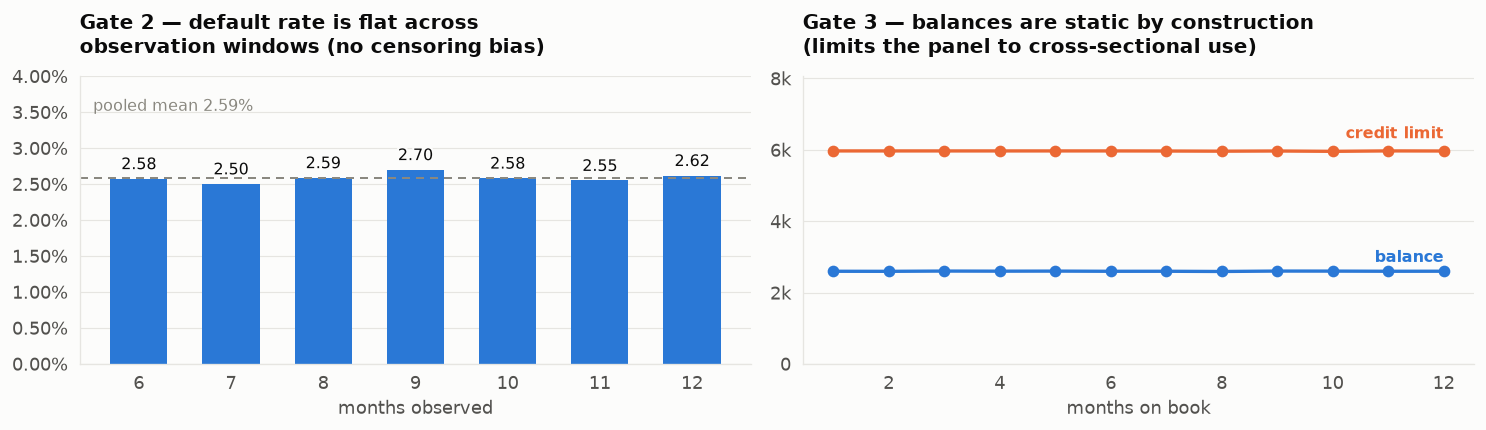

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.7))

bars = ax1.bar(cens.index.astype(str), cens.default_rate * 100, color=BLUES[3], width=0.62)
ax1.axhline(outcome.default_12m.mean() * 100, color=MUTED, lw=1.2, ls=(0, (4, 3)))
ax1.set_ylim(0, 4); ax1.yaxis.set_major_formatter(PercentFormatter())
ax1.set_xlabel("months observed"); ax1.set_title("Gate 2 — default rate is flat across\nobservation windows (no censoring bias)")
label_bars(ax1, bars, "{:.2f}")
ax1.text(0.02, 0.88, f"pooled mean {outcome.default_12m.mean():.2%}", transform=ax1.transAxes,
         color=MUTED, fontsize=9.5)
style(ax1)

ax2.plot(traj.index, traj.bal, color=BLUE, marker="o", label="mean balance")
ax2.plot(traj.index, traj.lim, color=ORANGE, marker="o", label="mean credit limit")
ax2.set_ylim(0, traj.lim.max() * 1.35); ax2.set_xlabel("months on book")
ax2.yaxis.set_major_formatter(thousands)
ax2.set_title("Gate 3 — balances are static by construction\n(limits the panel to cross-sectional use)")
ax2.text(traj.index[-1], traj.lim.iloc[-1] * 1.06, "credit limit", color=ORANGE, ha="right",
         fontsize=9.5, fontweight="bold")
ax2.text(traj.index[-1], traj.bal.iloc[-1] * 1.10, "balance", color=BLUE, ha="right",
         fontsize=9.5, fontweight="bold")
style(ax2)
plt.tight_layout(); plt.show()

**What the gates permit.** Gates 1 and 2 pass cleanly, and Gate 2 matters more than it looks:
because the length of the observation window is unrelated to when someone applied, default rates
can be compared across any segments without vintage adjustment or survival modelling. That makes
the rest of the analysis much more direct than a real portfolio would allow.

**What they forbid.** Gate 3 shows balances and limits are constant across months-on-book to
within 0.2% — the panel has no genuine dynamics, so *time-to-default, utilisation drift and
delinquency-roll analysis are all off the table* and I do not attempt them. Gate 4 is the
binding one: with zero outcomes for declined applicants, no amount of modelling on the approved
book can honestly estimate how declined applicants would have performed.

One sanity note on the label: `default_flag_12m` is broader than 90+ days past due. Of 7,750
flagged defaults, 2,173 reach 90+ DPD while the rest default without ever crossing it, and no
non-defaulter exceeds 29 DPD. The flag is the ground truth used throughout; DPD is only a
partial correlate.

In [13]:
agree = pd.crosstab(outcome.default_12m.map({True: "default_12m = True", False: "default_12m = False"}),
                    (outcome.max_dpd >= 90).map({True: "reached 90+ DPD", False: "never 90+ DPD"}))
print(agree.to_string(), "\n")
print(outcome.groupby("default_12m").max_dpd.describe()[["count", "mean", "50%", "max"]].to_string())

max_dpd              never 90+ DPD  reached 90+ DPD
default_12m                                        
default_12m = False         291455                0
default_12m = True            5577             2173 

                  count   mean    50%     max
default_12m                                  
False       291,455.000  6.844  0.000  29.000
True          7,750.000 50.078 19.000 180.000


## 5 · The natural experiment: `pilot_holdout`

Gate 4 leaves the central question unanswerable — unless the data contains a population that was
approved *despite* failing policy. It does. The `approval_channel` field has a third value
besides `policy` and `n/a`:

In [14]:
print(df.approval_channel.value_counts().to_string(), "\n")

hold = df[df.policy_reason == "approved_pilot_holdout"]
print(f"pilot_holdout: {len(hold):,} approvals, of which {(~hold.bureau_hit).sum():,} "
      f"({(~hold.bureau_hit).mean():.1%}) have NO bureau record")
print("\nBy bureau status — holdout vs the policy-approved book:")
print(df[df.policy_reason.isin(["approved_pilot_holdout", "approved_policy"])]
        .groupby(["policy_reason", "bureau_hit"])
        .agg(accounts=("default_12m", "size"), default_rate=("default_12m", "mean"),
             mean_limit=("approved_limit_mxn", "mean"), mean_balance=("avg_balance_mxn", "mean"))
        .to_string())

approval_channel
policy           282781
n/a              220795
pilot_holdout     16424 

pilot_holdout: 16,424 approvals, of which 11,593 (70.6%) have NO bureau record

By bureau status — holdout vs the policy-approved book:
                                   accounts default_rate  mean_limit  mean_balance
policy_reason          bureau_hit                                                 
approved_pilot_holdout False          11593        0.052   2,671.880     1,165.952
                       True            4831        0.064   2,495.736     1,094.291
approved_policy        False           9921        0.017   7,659.117     3,331.930
                       True          272860        0.024   6,104.960     2,658.404


**11,593 thin-file applicants were approved through the holdout** — people the policy gate would
otherwise have rejected — and their repayment is observed. This is the counterfactual sample for
the 156,944 declined, and it is the only part of the data that can support a credible estimate.

Its value depends entirely on whether holdout assignment was **random** with respect to risk. If
the pilot cherry-picked promising applicants, its default rate understates the declined
population. So test balance on every covariate available at decision time:

Largest imbalance on any covariate: |std diff| = 0.018 (age)
Covariates outside the +/-0.1 balance band: 0 of 13


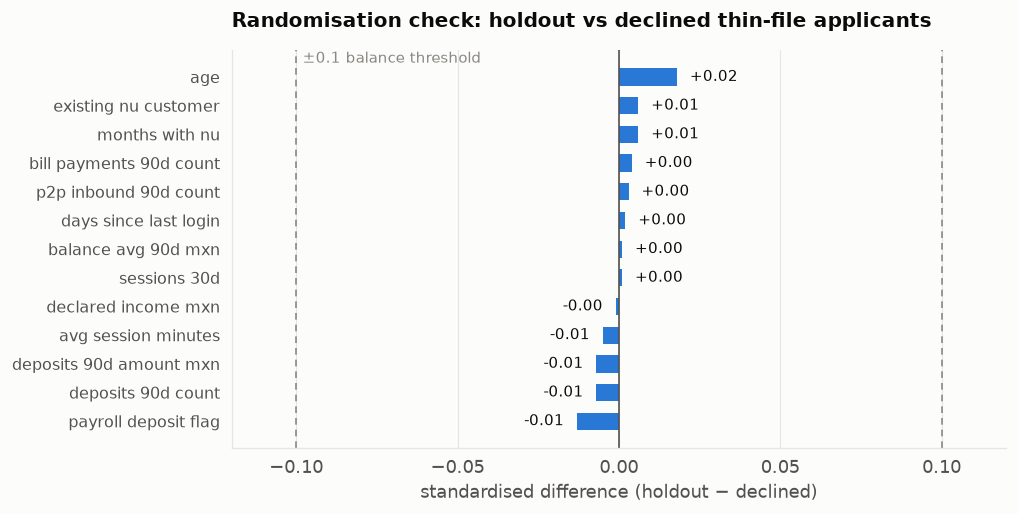

,holdout (approved),declined (no bureau),std_diff,rel_diff_%
payroll_deposit_flag,0.196,0.201,-0.013,-2.600
deposits_90d_count,2.341,2.355,-0.007,-0.600
deposits_90d_amount_mxn,"5,436.312","5,484.308",-0.007,-0.900
avg_session_minutes,2.632,2.641,-0.005,-0.300
declared_income_mxn,"10,202.907","10,211.615",-0.001,-0.100
sessions_30d,12.160,12.154,0.001,0.000
balance_avg_90d_mxn,"2,293.409","2,290.311",0.001,0.100
days_since_last_login,3.167,3.162,0.002,0.200
p2p_inbound_90d_count,2.388,2.383,0.003,0.200
bill_payments_90d_count,1.478,1.472,0.004,0.400


In [15]:
COVARIATES = ["declared_income_mxn", "age", "months_with_nu", "existing_nu_customer",
              "sessions_30d", "avg_session_minutes", "deposits_90d_count",
              "deposits_90d_amount_mxn", "balance_avg_90d_mxn", "payroll_deposit_flag",
              "p2p_inbound_90d_count", "bill_payments_90d_count", "days_since_last_login"]

thin = df[df.thin_file].copy()
thin_hold = thin[thin.policy_reason == "approved_pilot_holdout"]
thin_decl = thin[thin.policy_reason == "declined_no_bureau_history"]

bal = pd.DataFrame({
    "holdout (approved)":   thin_hold[COVARIATES].mean(),
    "declined (no bureau)": thin_decl[COVARIATES].mean(),
})
# Standardised difference: the conventional balance diagnostic for randomisation.
pooled_sd = np.sqrt((thin_hold[COVARIATES].var() + thin_decl[COVARIATES].var()) / 2)
bal["std_diff"] = ((bal["holdout (approved)"] - bal["declined (no bureau)"]) / pooled_sd).round(3)
bal["rel_diff_%"] = ((bal["holdout (approved)"] / bal["declined (no bureau)"] - 1) * 100).round(1)
bal = bal.sort_values("std_diff")
print(f"Largest imbalance on any covariate: |std diff| = {bal.std_diff.abs().max():.3f} "
      f"({bal.std_diff.abs().idxmax()})")
print(f"Covariates outside the +/-0.1 balance band: {(bal.std_diff.abs() > 0.1).sum()} of {len(bal)}")

fig, ax = plt.subplots(figsize=(8.6, 4.4))
colors = [ORANGE if abs(v) > 0.1 else BLUE for v in bal.std_diff]
bars = ax.barh(range(len(bal)), bal.std_diff, color=colors, height=0.6)
ax.set_yticks(range(len(bal))); ax.set_yticklabels([c.replace("_", " ") for c in bal.index], fontsize=9.5)
ax.axvline(0, color=INK2, lw=1)
for x in (-0.1, 0.1):
    ax.axvline(x, color=MUTED, lw=1, ls=(0, (4, 3)))
ax.set_xlim(-0.12, 0.12); ax.set_xlabel("standardised difference (holdout − declined)")
ax.set_title("Randomisation check: holdout vs declined thin-file applicants")
ax.text(-0.098, len(bal) - 0.5, "±0.1 balance threshold", color=MUTED, fontsize=9, ha="left")
for b, v in zip(bars, bal.std_diff):
    ax.text(v + (0.004 if v >= 0 else -0.004), b.get_y() + b.get_height()/2, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9, color=INK)
style(ax, xgrid=True, ygrid=False); plt.tight_layout(); plt.show()

bal

**The holdout is cleanly randomised.**

All thirteen covariates sit far inside the conventional ±0.1 standardised-difference band — the
largest imbalance on any variable is **0.018**, and the biggest relative gap is 2.6% (payroll
deposit: 19.6% vs 20.1%). Income differs by 0.1%, deposit volume by 0.9%, age by 0.5%. This is
what genuine random assignment looks like, and it is the single most important property of this
dataset for the analysis that follows.

Because assignment is random with respect to every observable, the holdout's **5.18% default
rate is an unbiased estimate** of what the 156,944 declined thin-file applicants would have
produced had they all been approved — and, more usefully, a model fitted on it estimates
unbiased risk *rankings* for that population. Without this, §7 would not be defensible at all.

## 6 · Does behavioural data carry risk signal where the bureau is silent?

In [16]:
print(f"Thin-file holdout: n = {len(thin_hold):,}, defaults = {int(thin_hold.default_12m.sum()):,}, "
      f"rate = {thin_hold.default_12m.mean():.2%}")
book_dr = df[df.policy_reason == "approved_policy"].default_12m.mean()
print(f"Current policy-approved book: n = {(df.policy_reason=='approved_policy').sum():,}, "
      f"rate = {book_dr:.2%}")

Thin-file holdout: n = 11,593, defaults = 600, rate = 5.18%
Current policy-approved book: n = 282,781, rate = 2.42%


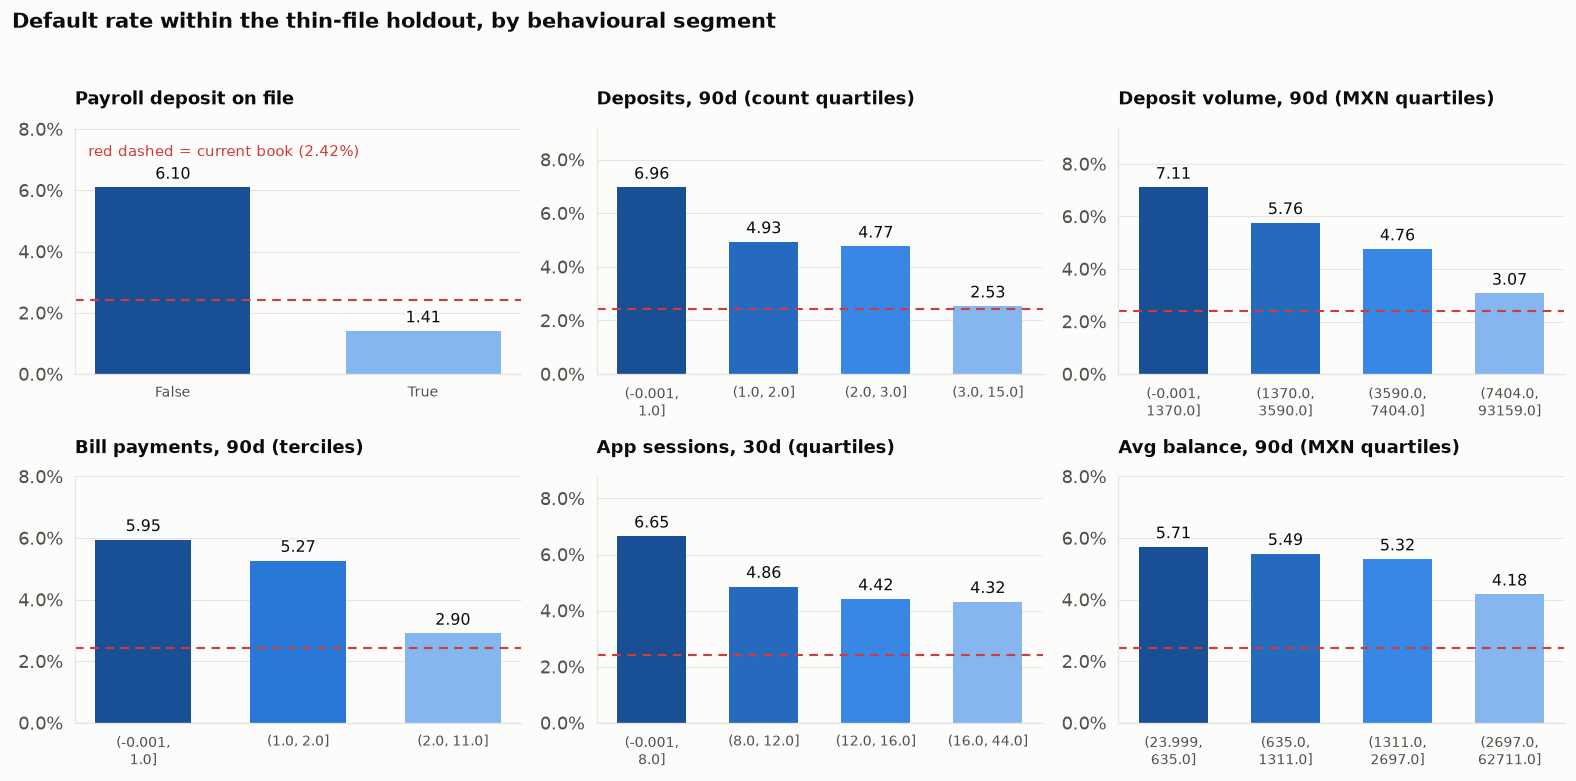

In [17]:
def segment_rates(frame, col, q=4):
    """Default rate by segment, with counts, for a boolean or a quartiled numeric."""
    s = frame[col]
    if s.dtype == bool:
        g = frame.groupby(col)
    else:
        g = frame.groupby(pd.qcut(s, q, duplicates="drop"))
    out = g.default_12m.agg(n="size", rate="mean").reset_index()
    out.columns = ["segment", "n", "rate"]
    out["segment"] = out.segment.astype(str)
    return out

DRIVERS = ["payroll_deposit_flag", "deposits_90d_count", "deposits_90d_amount_mxn",
           "bill_payments_90d_count", "sessions_30d", "balance_avg_90d_mxn"]
TITLES  = ["Payroll deposit on file", "Deposits, 90d (count quartiles)",
           "Deposit volume, 90d (MXN quartiles)", "Bill payments, 90d (terciles)",
           "App sessions, 30d (quartiles)", "Avg balance, 90d (MXN quartiles)"]

fig, axes = plt.subplots(2, 3, figsize=(13.2, 6.6))
for ax, col, title in zip(axes.ravel(), DRIVERS, TITLES):
    t = segment_rates(thin_hold, col)
    ramp = [BLUES[i] for i in np.linspace(0, 6, len(t)).astype(int)][::-1]
    bars = ax.bar(range(len(t)), t.rate * 100, color=ramp, width=0.62)
    ax.axhline(book_dr * 100, color=CRITICAL, lw=1.3, ls=(0, (4, 3)))
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([s.replace(", ", ",\n") if len(s) > 12 else s for s in t.segment], fontsize=8.5)
    ax.set_ylim(0, max(t.rate.max() * 100 * 1.32, 8))
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(title, fontsize=10.5)
    label_bars(ax, bars, "{:.2f}")
    style(ax)
axes[0, 0].text(0.03, 0.93, "red dashed = current book (2.42%)", transform=axes[0, 0].transAxes,
                color=CRITICAL, fontsize=8.8, va="top")
fig.suptitle("Default rate within the thin-file holdout, by behavioural segment",
             x=0.008, ha="left", fontsize=12.5, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.955]); plt.show()

In [18]:
pay = segment_rates(thin_hold, "payroll_deposit_flag")
lo, hi = pay.loc[pay.segment == "True", "rate"].iloc[0], pay.loc[pay.segment == "False", "rate"].iloc[0]
print(f"payroll_deposit_flag: {hi:.2%} (absent) vs {lo:.2%} (present) — a {hi/lo:.1f}x spread")
print(f"  thin-file applicants WITH a payroll deposit default BELOW the current book "
      f"({lo:.2%} vs {book_dr:.2%})")
dep = segment_rates(thin_hold, "deposits_90d_amount_mxn")
print(f"\ndeposit volume: {dep.rate.iloc[0]:.2%} (bottom quartile) vs {dep.rate.iloc[-1]:.2%} (top) "
      f"— {dep.rate.iloc[0]/dep.rate.iloc[-1]:.1f}x spread, monotone across all four")

payroll_deposit_flag: 6.10% (absent) vs 1.41% (present) — a 4.3x spread
  thin-file applicants WITH a payroll deposit default BELOW the current book (1.41% vs 2.42%)

deposit volume: 7.11% (bottom quartile) vs 3.07% (top) — 2.3x spread, monotone across all four


**Behavioural data separates risk in exactly the population where the bureau is blank.**

A single binary feature — whether a payroll deposit lands in the Nu account — splits thin-file
default **1.41% vs 6.10%, a 4.3× spread**. Deposit volume is cleanly monotone across quartiles
(7.11% → 3.07%), as are deposit count, bill payments and app engagement.

The result that matters commercially: **thin-file applicants with a payroll deposit default at
1.41%, materially below the 2.42% of the book being approved today.** The policy gate is
currently rejecting a segment that is *safer than the average account it accepts*.

Two things run against intuition and are worth flagging rather than burying:
`days_since_last_login` carries almost no signal, and in the fitted model (§7)
`existing_nu_customer` holds the only material *risk-raising* coefficient (+0.11) while tenure
(`months_with_nu`, −0.02) contributes essentially nothing. Relationship length with Nu is not a
proxy for creditworthiness here — transactional intensity is.

## 7 · A scorecard for the credit-invisible, and the size of the prize

Combining the behavioural features into one score gives a ranking, which is what an approval
policy actually needs. Trained **only on the 11,593 thin-file holdout accounts** — the randomised
sample — so that it learns the relationship on the population it will be applied to, and scored
**out-of-fold** so the reported discrimination is honest.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

FEATURES = COVARIATES
X = thin_hold[FEATURES].astype(float).values
y = thin_hold.default_12m.astype(int).values
cv = StratifiedKFold(5, shuffle=True, random_state=42)

candidates = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "gradient boosting":   HistGradientBoostingClassifier(max_depth=3, max_iter=250,
                                                          learning_rate=0.05, random_state=42),
}
oof = {}
for name, model in candidates.items():
    p = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    oof[name] = p
    print(f"{name:22s} out-of-fold AUC = {roc_auc_score(y, p):.4f}")

# Logistic wins: with only ~600 defaults the GBM overfits. Prefer it for auditability too.
scorer = candidates["logistic regression"]
thin_hold = thin_hold.assign(pd_hat=oof["logistic regression"])
scorer.fit(X, y)
coefs = (pd.Series(scorer[-1].coef_[0], index=FEATURES)
           .sort_values().rename("standardised coefficient").to_frame())
coefs["direction"] = np.where(coefs.iloc[:, 0] < 0, "lowers risk", "raises risk")
coefs

logistic regression    out-of-fold AUC = 0.6141
gradient boosting      out-of-fold AUC = 0.5868


,standardised coefficient,direction
payroll_deposit_flag,-0.450,lowers risk
deposits_90d_count,-0.232,lowers risk
balance_avg_90d_mxn,-0.120,lowers risk
age,-0.095,lowers risk
p2p_inbound_90d_count,-0.074,lowers risk
declared_income_mxn,-0.061,lowers risk
deposits_90d_amount_mxn,-0.036,lowers risk
months_with_nu,-0.023,lowers risk
sessions_30d,-0.023,lowers risk
bill_payments_90d_count,-0.005,lowers risk


AUC **0.614** — modest, and stated plainly. Two things put it in context: it is achieved on a
population where the incumbent policy has *no* discrimination at all (it rejects everyone), and
the training set contains only ~600 defaults. The gradient booster scores lower, which is the
expected signature of overfitting at this event count; the logistic model is also the auditable
choice for a regulated credit decision.

The operative question is not AUC but whether the ranking is good enough to carve out a
safe-to-approve tranche.

In [20]:
ranked = thin_hold.sort_values("pd_hat").reset_index(drop=True)
n_declined_thin = len(thin_decl)

rows = []
for q in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.75, 1.00]:
    k = max(int(len(ranked) * q), 1)
    sub = ranked.iloc[:k]
    p, n = sub.default_12m.mean(), len(sub)
    se = np.sqrt(p * (1 - p) / n)
    ci_lo, ci_hi = max(p - 1.96 * se, 0), p + 1.96 * se
    verdict = ("below book" if ci_hi < book_dr else
               "above book" if ci_lo > book_dr else "indistinguishable")
    rows.append({"approve safest": f"{q:.0%}", "n (holdout)": n,
                 "default rate": p, "95% CI low": ci_lo, "95% CI high": ci_hi,
                 "vs book (2.42%)": verdict,
                 "scaled approvals/yr": int(n_declined_thin * q)})
cuts = pd.DataFrame(rows)
cuts.style.format({"default rate": "{:.2%}", "95% CI low": "{:.2%}", "95% CI high": "{:.2%}",
                   "n (holdout)": "{:,}", "scaled approvals/yr": "{:,}"})

,approve safest,n (holdout),default rate,95% CI low,95% CI high,vs book (2.42%),scaled approvals/yr
0,10%,"1,159",1.21%,0.58%,1.84%,below book,"15,694"
1,15%,"1,738",1.27%,0.74%,1.79%,below book,"23,541"
2,20%,"2,318",1.55%,1.05%,2.06%,below book,"31,388"
3,25%,"2,898",2.28%,1.73%,2.82%,indistinguishable,"39,236"
4,30%,"3,477",2.39%,1.88%,2.89%,indistinguishable,"47,083"
5,35%,"4,057",2.66%,2.17%,3.16%,indistinguishable,"54,930"
6,40%,"4,637",3.00%,2.51%,3.49%,above book,"62,777"
7,50%,"5,796",3.49%,3.01%,3.96%,above book,"78,472"
8,75%,"8,694",4.53%,4.09%,4.97%,above book,"117,708"
9,100%,"11,593",5.18%,4.77%,5.58%,above book,"156,944"


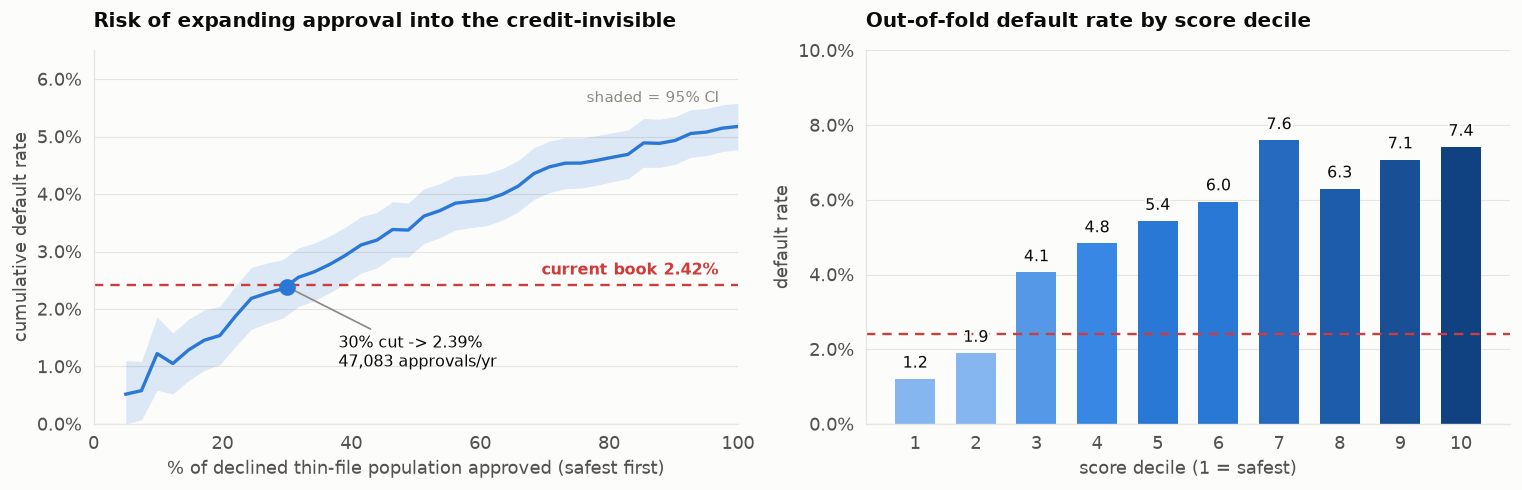

Decile 1 defaults at 1.21% vs decile 10 at 7.41% — 6.1x lift.
Deciles at or below the current book (2.42%): 2 of 10 -> 1, 2
Strictly monotone across deciles: False


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.2))

# --- Cumulative default rate as the approval cut loosens, with CI band ---
qs = np.linspace(0.05, 1.0, 40)
cum, lo_b, hi_b = [], [], []
for q in qs:
    sub = ranked.iloc[:max(int(len(ranked) * q), 1)]
    p, n = sub.default_12m.mean(), len(sub)
    se = np.sqrt(p * (1 - p) / n)
    cum.append(p * 100); lo_b.append(max(p - 1.96*se, 0) * 100); hi_b.append((p + 1.96*se) * 100)

ax1.fill_between(qs * 100, lo_b, hi_b, color=BLUE, alpha=0.15, linewidth=0)
ax1.plot(qs * 100, cum, color=BLUE)
ax1.axhline(book_dr * 100, color=CRITICAL, lw=1.4, ls=(0, (4, 3)))
ax1.set_xlabel("% of declined thin-file population approved (safest first)")
ax1.set_ylabel("cumulative default rate")
ax1.yaxis.set_major_formatter(PercentFormatter())
ax1.set_xlim(0, 100); ax1.set_ylim(0, 6.5)
ax1.set_title("Risk of expanding approval into the credit-invisible")
ax1.text(97, book_dr * 100 + 0.18, "current book 2.42%", color=CRITICAL, ha="right",
         fontsize=9.5, fontweight="bold")
ax1.text(97, 5.6, "shaded = 95% CI", color=MUTED, ha="right", fontsize=9)
# mark the operating point (derived, not hardcoded)
op_q = 0.30
op_dr = ranked.iloc[:int(len(ranked) * op_q)].default_12m.mean() * 100
ax1.plot([op_q * 100], [op_dr], marker="o", ms=9, color=BLUE, zorder=5)
ax1.annotate(f"{op_q:.0%} cut -> {op_dr:.2f}%\n{int(n_declined_thin*op_q):,} approvals/yr",
             xy=(op_q * 100, op_dr), xytext=(38, 1.0), fontsize=9.5, color=INK,
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
style(ax1)

# --- Decile lift: is the ranking monotone? ---
ranked["decile"] = pd.qcut(ranked.pd_hat, 10, labels=False, duplicates="drop")
dec_tab = ranked.groupby("decile").default_12m.agg(n="size", rate="mean")
ramp = [BLUES[i] for i in np.linspace(0, 7, len(dec_tab)).astype(int)]
bars = ax2.bar(dec_tab.index + 1, dec_tab.rate * 100, color=ramp, width=0.66)
ax2.axhline(book_dr * 100, color=CRITICAL, lw=1.4, ls=(0, (4, 3)))
ax2.set_xlabel("score decile (1 = safest)"); ax2.set_ylabel("default rate")
ax2.yaxis.set_major_formatter(PercentFormatter()); ax2.set_ylim(0, 10)
ax2.set_xticks(dec_tab.index + 1)
ax2.set_title("Out-of-fold default rate by score decile")
label_bars(ax2, bars, "{:.1f}")
style(ax2)
plt.tight_layout(); plt.show()

at_or_below = int((dec_tab.rate <= book_dr).sum())
print(f"Decile 1 defaults at {dec_tab.rate.iloc[0]:.2%} vs decile 10 at {dec_tab.rate.iloc[-1]:.2%} "
      f"— {dec_tab.rate.iloc[-1]/dec_tab.rate.iloc[0]:.1f}x lift.")
print(f"Deciles at or below the current book ({book_dr:.2%}): {at_or_below} of {len(dec_tab)} "
      f"-> {', '.join(str(d+1) for d in dec_tab.index[dec_tab.rate <= book_dr])}")
print(f"Strictly monotone across deciles: {bool((dec_tab.rate.diff().dropna() >= 0).all())}")

### Reading the result honestly

The ranking is good enough to carve out a safe tranche, and the confidence intervals decide
exactly how large that tranche can honestly be claimed to be:

- **Up to a 20% cut, the entire interval sits below the book.** Default is 1.55% [1.05, 2.06]
  against 2.42%. This is a statistically solid expansion of **~31,000 approvals/year**.
- **From 25% to 35%, the interval straddles 2.42%.** The 30% cut's 2.39% [1.88, 2.89] is *not*
  significantly better than the book — the defensible claim is "indistinguishable from current
  risk", not "safer". That still supports **~47,000 approvals/year at risk parity**.
- **At 40% and beyond, default is significantly worse** (3.00% [2.51, 3.49]) and the tranche
  should not be approved on this evidence.

So the finding is a range, not a point: **~31,000 approvals/year at demonstrably below-book
risk, extending to ~47,000 at risk parity** — with the upper end resting on roughly 83 observed
defaults, which is thin.

The honest limitation: this scorecard is trained on 11,593 accounts and 600 defaults. That is
enough to justify a **larger, staged holdout** — not enough to switch the policy on wholesale.

## 8 · Underwriting operations: where the effort goes

The funnel has a second, independent problem. The same thin-file applications that are almost
always declined are also the ones consuming the most human review.

In [22]:
by_path = (df.groupby("policy_reason")
             .agg(applications=("application_id", "size"),
                  manual_review=("manual_review_flag", "mean"),
                  docs_requested=("documents_requested", "mean"),
                  median_latency_h=("decision_latency_hours", "median"),
                  mean_latency_h=("decision_latency_hours", "mean"),
                  analyst_minutes=("analyst_review_minutes", "mean"),
                  rework=("reworked_flag", "mean"),
                  abandoned=("abandoned_before_decision", "mean"))
             .sort_values("applications", ascending=False))
by_path

,applications,manual_review,docs_requested,median_latency_h,mean_latency_h,analyst_minutes,rework,abandoned
policy_reason,,,,,,,,
approved_policy,282781,0.196,0.493,2.850,13.310,2.360,0.041,0.029
declined_no_bureau_history,156944,0.546,1.913,32.280,36.505,6.627,0.114,0.100
declined_low_bureau_score,53248,0.194,0.466,2.840,13.051,2.367,0.041,0.027
approved_pilot_holdout,16424,0.441,1.490,5.460,29.507,5.244,0.096,0.081
declined_insufficient_income,10603,0.206,0.499,2.880,13.508,2.532,0.044,0.031


In [23]:
total_analyst_h = df.analyst_review_minutes.sum() / 60
thin_decl_h     = thin_decl.analyst_review_minutes.sum() / 60
FTE_HOURS       = 2_080  # one analyst-year

print(f"Total analyst effort in the window      : {total_analyst_h:>10,.0f} hours  (~{total_analyst_h/FTE_HOURS:.1f} FTE)")
print(f"Spent on thin-file applications later declined: {thin_decl_h:>10,.0f} hours  "
      f"(~{thin_decl_h/FTE_HOURS:.1f} FTE, {thin_decl_h/total_analyst_h:.0%} of all effort)")
thin_decline_rate = (~df[df.thin_file].approved).mean()
print(f"\nThin-file applications are sent to manual review {thin_decl.manual_review_flag.mean():.0%} of the time,")
print(f"versus {df[~df.thin_file].manual_review_flag.mean():.0%} for applications with a bureau record —")
print(f"and {thin_decline_rate:.0%} of thin-file applications are declined by a deterministic gate")
print(f"that needs no human judgement (median decision time "
      f"{thin_decl.decision_latency_hours.median():.0f}h vs "
      f"{df[~df.manual_review_flag].decision_latency_hours.median():.1f}h automated).")

Total analyst effort in the window      :     32,440 hours  (~15.6 FTE)
Spent on thin-file applications later declined:     17,334 hours  (~8.3 FTE, 53% of all effort)

Thin-file applications are sent to manual review 55% of the time,
versus 19% for applications with a bureau record —
and 88% of thin-file applications are declined by a deterministic gate
that needs no human judgement (median decision time 32h vs 2.1h automated).


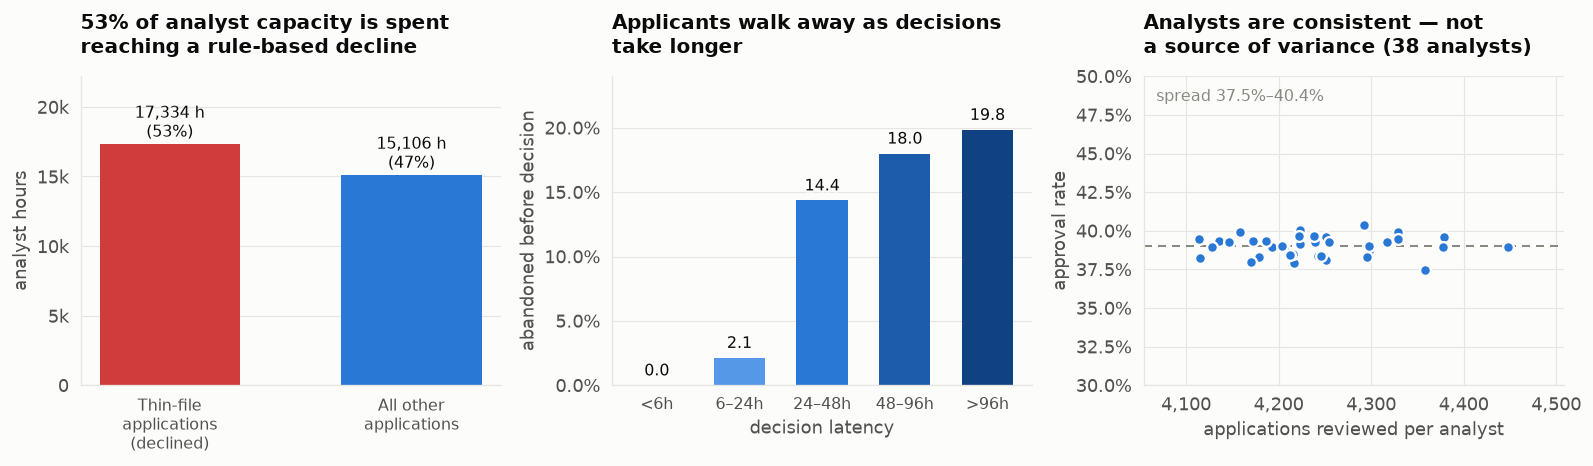

Abandonment rises from 0.0% (<6h) to 19.8% (>96h).
Manual review: 61h mean latency vs 2.6h automated; rework 21%; abandonment 17%.


In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.4, 4.0))

# --- 1. Analyst hours: thin-file declines vs everything else ---
split = pd.Series({"Thin-file\napplications\n(declined)": thin_decl_h,
                   "All other\napplications": total_analyst_h - thin_decl_h})
bars = ax1.bar(range(2), split.values, color=[CRITICAL, BLUES[3]], width=0.58)
ax1.set_xticks(range(2)); ax1.set_xticklabels(split.index, fontsize=9.5)
ax1.set_ylabel("analyst hours"); ax1.yaxis.set_major_formatter(thousands)
ax1.set_ylim(0, split.max() * 1.28)
for b, v in zip(bars, split.values):
    ax1.text(b.get_x() + b.get_width()/2, v + split.max()*0.03,
             f"{v:,.0f} h\n({v/total_analyst_h:.0%})", ha="center", fontsize=9.5, color=INK)
ax1.set_title("53% of analyst capacity is spent\nreaching a rule-based decline")
style(ax1)

# --- 2. Latency -> abandonment ---
df["latency_band"] = pd.cut(df.decision_latency_hours, [0, 6, 24, 48, 96, 300],
                            labels=["<6h", "6–24h", "24–48h", "48–96h", ">96h"])
ab = (df.groupby("latency_band", observed=True)
        .agg(n=("application_id", "size"), abandoned=("abandoned_before_decision", "mean")))
bars = ax2.bar(range(len(ab)), ab.abandoned * 100,
               color=[BLUES[i] for i in np.linspace(0, 7, len(ab)).astype(int)], width=0.62)
ax2.set_xticks(range(len(ab))); ax2.set_xticklabels(ab.index, fontsize=9.5)
ax2.set_xlabel("decision latency"); ax2.set_ylabel("abandoned before decision")
ax2.yaxis.set_major_formatter(PercentFormatter()); ax2.set_ylim(0, 24)
label_bars(ax2, bars, "{:.1f}")
ax2.set_title("Applicants walk away as decisions\ntake longer")
style(ax2)

# --- 3. Analyst-level consistency ---
per_analyst = (df[df.manual_review_flag].groupby("analyst_id")
                 .agg(n=("application_id", "size"), approval_rate=("approved", "mean")))
ax3.scatter(per_analyst.n, per_analyst.approval_rate * 100, s=42, color=BLUE,
            edgecolor=SURFACE, linewidth=1.4, zorder=3)
ax3.axhline(per_analyst.approval_rate.mean() * 100, color=MUTED, lw=1.2, ls=(0, (4, 3)))
ax3.set_xlabel("applications reviewed per analyst"); ax3.set_ylabel("approval rate")
ax3.yaxis.set_major_formatter(PercentFormatter()); ax3.set_ylim(30, 50)
# NOT the `thousands` formatter here: the range is 4.1k-4.4k, which it would round to "4k" everywhere.
ax3.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax3.set_xlim(per_analyst.n.min() - 60, per_analyst.n.max() + 60)
ax3.set_title(f"Analysts are consistent — not\na source of variance ({len(per_analyst)} analysts)")
ax3.text(0.03, 0.92, f"spread {per_analyst.approval_rate.min():.1%}–{per_analyst.approval_rate.max():.1%}",
         transform=ax3.transAxes, color=MUTED, fontsize=9.5)
style(ax3, xgrid=True)
plt.tight_layout(); plt.show()

print(f"Abandonment rises from {ab.abandoned.iloc[0]:.1%} (<6h) to {ab.abandoned.iloc[-1]:.1%} (>96h).")
print(f"Manual review: {df[df.manual_review_flag].decision_latency_hours.mean():.0f}h mean latency "
      f"vs {df[~df.manual_review_flag].decision_latency_hours.mean():.1f}h automated; "
      f"rework {df[df.manual_review_flag].reworked_flag.mean():.0%}; "
      f"abandonment {df[df.manual_review_flag].abandoned_before_decision.mean():.0%}.")

### Operational findings

1. **53% of all analyst effort — 17,334 hours, ~8.3 FTE — is spent reaching a decline that a
   rule already determines.** Thin-file applications go to manual review 55% of the time (vs 19%
   for bureau-hit applications), take a **32-hour median** decision versus 2.9 hours, and are then
   declined 88% of the time by the deterministic `bureau_hit == False` gate. The human review adds
   no decision content.

2. **Latency destroys applications.** Abandonment climbs from 0% under 6 hours to 19.8% beyond 96
   hours. Manual review averages 61 hours against 2.6 hours automated, and carries 21% rework and
   17% abandonment. Because thin-file applications are the ones queued longest, the slowest path
   is aimed at the population the business most wants to convert.

3. **Analyst behaviour is not the problem** — worth reporting precisely because it rules out an
   intervention. Across 38 analysts, approval rates span only 37.5%–40.4% and review time
   11.9–12.4 minutes. Variance is negligible; the cost is structural, in *what gets routed to
   humans*, not in who handles it. Analyst calibration or retraining would recover nothing.

## 9 · Economics

Sizing the opportunity requires revenue assumptions the dataset does not contain. Rather than
bury them, they are set out explicitly and varied. Exposure comes from the **observed** balances
of thin-file holdout accounts, so the one input that *can* be measured is measured.

In [25]:
# --- Observed inputs ------------------------------------------------------------------
EAD  = thin_hold.avg_balance_mxn.mean()      # observed mean balance, thin-file holdout
LIM  = thin_hold.approved_limit_mxn.mean()   # observed mean approved limit
print(f"Observed (thin-file holdout): mean balance {EAD:,.0f} MXN | mean limit {LIM:,.0f} MXN "
      f"| utilisation {EAD/LIM:.0%}")

# --- Stated assumptions ---------------------------------------------------------------
LGD          = 0.75    # loss given default, unsecured MXN card
COST_PER_ACC = 60      # annual servicing cost per account, MXN
ANALYST_COST = 180     # fully-loaded analyst cost per hour, MXN
APR_GRID     = [0.45, 0.60, 0.75]

econ = []
for apr in APR_GRID:
    for q in [0.20, 0.30]:
        sub  = ranked.iloc[:max(int(len(ranked) * q), 1)]
        dr   = sub.default_12m.mean()
        n    = int(n_declined_thin * q)
        rev  = EAD * apr
        loss = dr * EAD * LGD
        net  = rev - loss - COST_PER_ACC
        econ.append({"APR": f"{apr:.0%}", "approval cut": f"{q:.0%}",
                     "default rate": dr, "revenue/acct": rev, "credit loss/acct": loss,
                     "net/acct": net, "accounts/yr": n, "annual net (MXN m)": net * n / 1e6})
econ = pd.DataFrame(econ)
econ.style.format({"default rate": "{:.2%}", "revenue/acct": "{:,.0f}", "credit loss/acct": "{:,.0f}",
                   "net/acct": "{:,.0f}", "accounts/yr": "{:,}", "annual net (MXN m)": "{:,.1f}"})

Observed (thin-file holdout): mean balance 1,166 MXN | mean limit 2,672 MXN | utilisation 44%


,APR,approval cut,default rate,revenue/acct,credit loss/acct,net/acct,accounts/yr,annual net (MXN m)
0,45%,20%,1.55%,525,14,451,"31,388",14.2
1,45%,30%,2.39%,525,21,444,"47,083",20.9
2,60%,20%,1.55%,700,14,626,"31,388",19.6
3,60%,30%,2.39%,700,21,619,"47,083",29.1
4,75%,20%,1.55%,874,14,801,"31,388",25.1
5,75%,30%,2.39%,874,21,794,"47,083",37.4


In [26]:
ops_saving_h   = thin_decl_h * 0.80          # assumption: automation removes 80% of this review
ops_saving_mxn = ops_saving_h * ANALYST_COST

# Applications recovered by cutting latency on the thin-file path to the automated profile.
recoverable = thin_decl.abandoned_before_decision.sum()

print(f"Operational saving  : {ops_saving_h:,.0f} analyst hours  "
      f"(~{ops_saving_h/FTE_HOURS:.1f} FTE)  =  MXN {ops_saving_mxn/1e6:.1f}M/yr")
print(f"                      assumes automating the thin-file decision removes 80% of that review")
print(f"Abandonment recovery: {recoverable:,} thin-file applications currently abandoned before a decision\n")

lo = econ[(econ["approval cut"] == "20%") & (econ.APR == "60%")]["annual net (MXN m)"].iloc[0]
hi = econ[(econ["approval cut"] == "30%") & (econ.APR == "60%")]["annual net (MXN m)"].iloc[0]
print(f"At a 60% APR mid-case, credit expansion contributes MXN {lo:.0f}M–{hi:.0f}M/yr")
print(f"plus MXN {ops_saving_mxn/1e6:.1f}M/yr in released analyst capacity")
print(f"=> total MXN {lo + ops_saving_mxn/1e6:.0f}M–{hi + ops_saving_mxn/1e6:.0f}M/yr")

Operational saving  : 13,867 analyst hours  (~6.7 FTE)  =  MXN 2.5M/yr
                      assumes automating the thin-file decision removes 80% of that review
Abandonment recovery: 15,644 thin-file applications currently abandoned before a decision

At a 60% APR mid-case, credit expansion contributes MXN 20M–29M/yr
plus MXN 2.5M/yr in released analyst capacity
=> total MXN 22M–32M/yr


**Range, not a point estimate.** Across a 45–75% APR band and the two defensible approval cuts,
credit expansion is worth **MXN 14M–37M a year**, with a 60% APR mid-case of **MXN 20M
(statistically safe cut) to 29M (risk-parity cut)**. Released analyst capacity adds roughly
**MXN 2.5M/year** and ~6.7 FTE redeployed.

The revenue side is the soft part of this: APR, LGD and servicing cost are all assumptions, and
the observed 44% utilisation on a ~2,670 MXN limit makes per-account revenue small. The
**volume** conclusion (31k–47k additional approvals) rests on measured data; the peso figure
inherits the uncertainty of the assumptions above it.

## 10 · Findings and recommendations

### What the data shows

| # | Finding | Evidence |
|---|---|---|
| 1 | **157k applications/yr (30% of volume) are declined for absence of a bureau file, not for credit risk.** On income, age and Nu tenure they match the approved book within 5%. | §3 |
| 2 | **This population is not uniformly risky.** A **cleanly randomised** holdout of 11,593 thin-file approvals (max \|std diff\| 0.018) defaults at 5.18% overall — but behavioural data ranks it: payroll-deposit customers default at **1.41%**, below the current book's 2.42%. | §5–6 |
| 3 | **A behavioural scorecard supports 31k–47k additional approvals/yr.** The safest 20% defaults at 1.55% [1.05, 2.06] — significantly below book. The safest 30% at 2.39% is at risk parity. AUC 0.614 on ~600 defaults. | §7 |
| 4 | **53% of analyst capacity (17,334 h, ~8.3 FTE) is spent producing rule-determined declines.** Thin-file applications get 55% manual review and a 32-hour median decision, then are declined 88% of the time by a deterministic gate. | §8 |
| 5 | **Latency costs applications.** Abandonment rises 0% → 19.8% as decisions slow past 96 hours; the slowest path is pointed at the population the business most wants to convert. | §8 |
| 6 | **Analysts are not a source of variance** (approval 37.5–40.4% across 38 analysts). Calibration or retraining would recover nothing — the cost is in routing. | §8 |

### Recommendations

1. **Scale the holdout before changing policy.** The strongest claim this data supports is that a
   behavioural scorecard *ranks* thin-file risk. 600 defaults is not a mandate to switch the gate
   off. Run a staged randomised expansion at the 20% cut — where the CI sits entirely below book —
   sized to yield ~2,000 defaults, which would tighten the 30% estimate enough to decide on it.
2. **Automate the thin-file decline path now.** This needs no model and carries no credit risk:
   the gate is deterministic, so routing `bureau_hit == False` to manual review has no decision
   value. Releases ~6.7 FTE and removes a 32-hour median wait.
3. **Treat decision latency as a conversion metric**, with the thin-file path targeted first —
   it is both the slowest and the highest-abandonment segment.
4. **Start with the payroll-deposit segment.** It needs no scorecard to defend: a single observable
   attribute identifies thin-file applicants who default *below* the current book.

### Limitations

- **Reject inference is only partially resolved.** The holdout covers 11,593 of 156,944 declined
  thin-file applicants (7.4%). Estimates rest on that sample; the 30% cut leans on ~83 defaults,
  which is why its interval straddles the book rather than clearing it.
- **Discrimination is modest** (AUC 0.614). The scorecard is a usable *ranking* device on a
  population the current policy does not rank at all, not a precise PD estimator.
- **The panel has no dynamics** (Gate 3): balances and limits are static, so time-to-default,
  utilisation drift and delinquency-roll analysis are not possible here.
- **Peso figures are assumption-driven.** APR, LGD and servicing cost are inputs, not data.
  Approval-volume conclusions are measured; revenue conclusions are modelled.
- **Behavioural features are only observable for existing Nu users** with app and deposit
  activity. Roughly 41% of thin-file applicants are not existing Nu customers, so the scorecard
  does not extend to them without further work — the addressable population is smaller than the
  full 157k.